# Football Transfer Market Analytics Dashboard
**Track C — Advanced Schema and Analytics Platform**  
Dataset: Transfermarkt | Scope: Premier League + La Liga, 2015–2023

---

In [1]:
# ── Imports ──────────────────────────────────────────────────
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Style ─────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  '#0f0f0f',
    'axes.facecolor':    '#1a1a1a',
    'axes.edgecolor':    '#333333',
    'axes.labelcolor':   '#cccccc',
    'axes.titlecolor':   '#ffffff',
    'axes.titlesize':    14,
    'axes.labelsize':    11,
    'xtick.color':       '#888888',
    'ytick.color':       '#888888',
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'grid.color':        '#2a2a2a',
    'grid.linewidth':    0.6,
    'text.color':        '#cccccc',
    'font.family':       'monospace',
    'figure.titlesize':  16,
})

ACCENT   = '#00e5a0'   # green accent
ACCENT2  = '#e55a00'   # orange accent
ACCENT3  = '#5a8ae5'   # blue accent
BAR_COLS = [ACCENT, ACCENT2, ACCENT3, '#e5c000', '#a05ae5',
            '#e5005a', '#00c4e5', '#7ae500', '#e500c4', '#e58a00']

print('Setup complete.')

Setup complete.


In [2]:
# ── Database connection ───────────────────────────────────────
# Update password to match your PostgreSQL credentials
conn = psycopg2.connect(
    host     = 'localhost',
    port     = 5432,
    dbname   = 'football_analytics',
    user     = 'postgres',
    password = 'your_password_here'
)

def query(sql):
    """Run a SQL query and return a pandas DataFrame."""
    return pd.read_sql_query(sql, conn)

print('Connected to football_analytics.')

Connected to football_analytics.


---
## Chart 1 — Top 10 Clubs by Total Transfer Spend
Which clubs have spent the most on permanent transfers between 2015 and 2023?

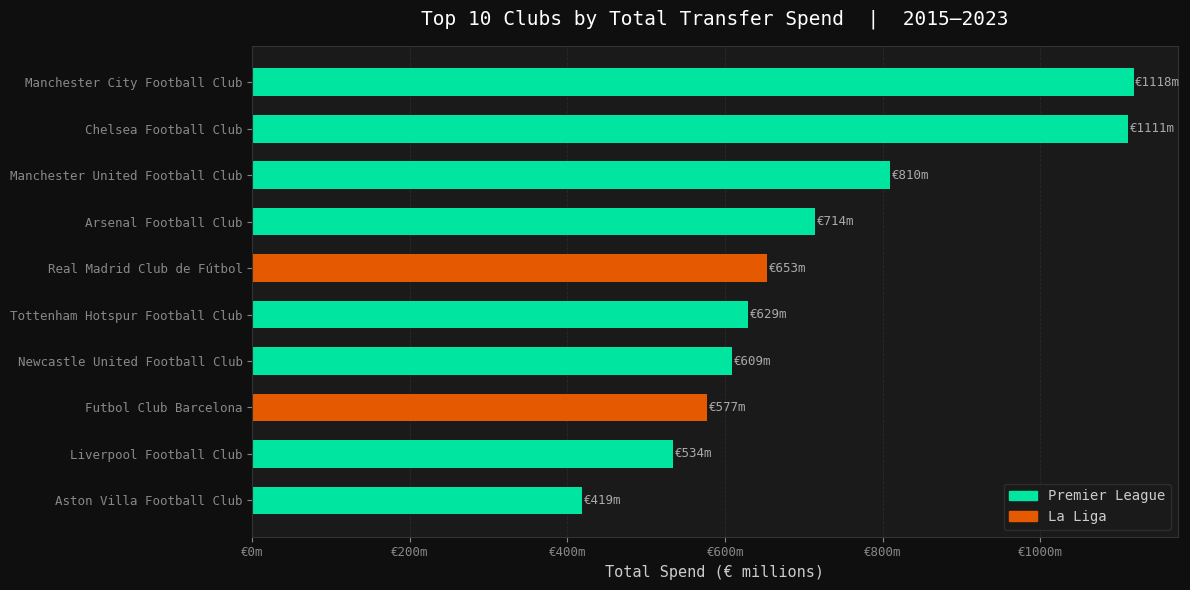

                           club         league  total_spent_millions
  Manchester City Football Club premier-league                1118.5
          Chelsea Football Club premier-league                1111.0
Manchester United Football Club premier-league                 809.8
          Arsenal Football Club premier-league                 714.5
     Real Madrid Club de Fútbol         laliga                 653.3
Tottenham Hotspur Football Club premier-league                 629.2
 Newcastle United Football Club premier-league                 609.1
          Futbol Club Barcelona         laliga                 577.1
        Liverpool Football Club premier-league                 533.7
      Aston Villa Football Club premier-league                 419.0


In [3]:
df1 = query("""
    SELECT
        c.name                              AS club,
        comp.name                           AS league,
        ROUND(SUM(t.fee_euros) / 1e6, 1)   AS total_spent_millions
    FROM   transfers      t
    JOIN   clubs          c    ON c.club_id          = t.to_club_id
    JOIN   competitions   comp ON comp.competition_id = c.competition_id
    JOIN   transfer_types tt   ON tt.transfer_type_id = t.transfer_type_id
    WHERE  tt.type_name = 'permanent'
    AND    t.fee_euros  IS NOT NULL
    GROUP  BY c.name, comp.name
    ORDER  BY total_spent_millions DESC
    LIMIT  10
""")

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#0f0f0f')

colors = [ACCENT if l == 'premier-league' else ACCENT2 for l in df1['league']]
bars = ax.barh(df1['club'], df1['total_spent_millions'], color=colors, height=0.6)

for bar, val in zip(bars, df1['total_spent_millions']):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'€{val:.0f}m', va='center', fontsize=9, color='#aaaaaa')

ax.invert_yaxis()
ax.set_xlabel('Total Spend (€ millions)')
ax.set_title('Top 10 Clubs by Total Transfer Spend  |  2015–2023', pad=15)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:.0f}m'))
ax.grid(axis='x', linestyle='--')
ax.set_axisbelow(True)

from matplotlib.patches import Patch
legend = [Patch(color=ACCENT, label='Premier League'),
          Patch(color=ACCENT2, label='La Liga')]
ax.legend(handles=legend, loc='lower right',
          facecolor='#1a1a1a', edgecolor='#333333', labelcolor='#cccccc')

plt.tight_layout()
plt.savefig('chart1_transfer_spend.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f0f')
plt.show()
print(df1.to_string(index=False))

---
## Chart 2 — Average Player Market Value by Age
At what age do players reach their peak market value?

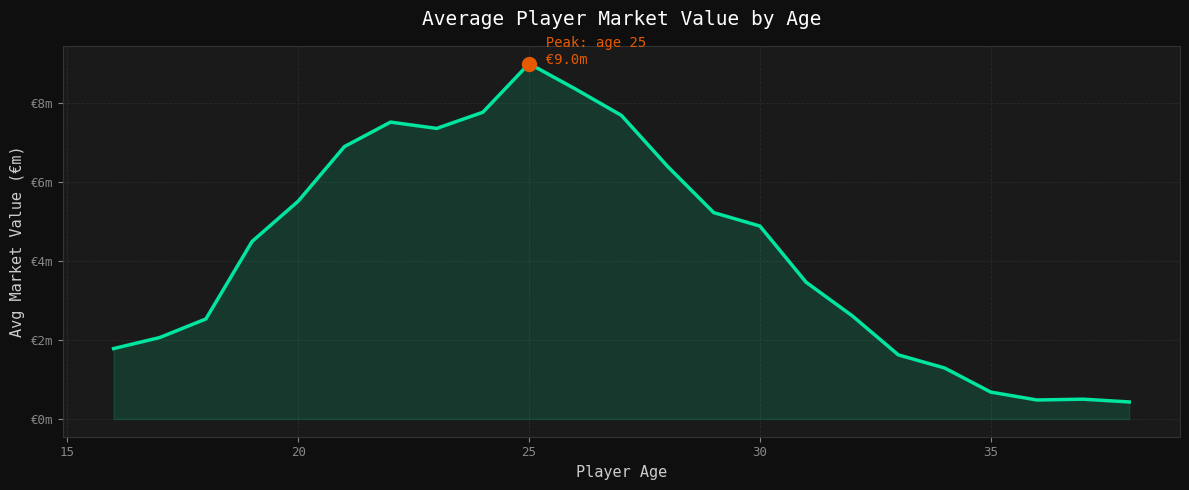

 age  avg_value_millions
  16                1.78
  17                2.06
  18                2.53
  19                4.49
  20                5.51
  21                6.89
  22                7.51
  23                7.35
  24                7.76
  25                8.99
  26                8.35
  27                7.68
  28                6.39
  29                5.22
  30                4.88
  31                3.46
  32                2.61
  33                1.62
  34                1.29
  35                0.68
  36                0.48
  37                0.50
  38                0.43


In [4]:
df2 = query("""
    SELECT
        DATE_PART('year', AGE(mv.valuation_date, p.date_of_birth))::int AS age,
        ROUND(AVG(mv.value_euros) / 1e6, 2)                            AS avg_value_millions
    FROM   market_valuations mv
    JOIN   players           p ON p.player_id = mv.player_id
    WHERE  p.date_of_birth IS NOT NULL
    AND    DATE_PART('year', AGE(mv.valuation_date, p.date_of_birth)) BETWEEN 16 AND 38
    GROUP  BY age
    ORDER  BY age
""")

peak_age = df2.loc[df2['avg_value_millions'].idxmax()]

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#0f0f0f')

ax.plot(df2['age'], df2['avg_value_millions'],
        color=ACCENT, linewidth=2.5, zorder=3)
ax.fill_between(df2['age'], df2['avg_value_millions'],
                alpha=0.15, color=ACCENT)

ax.scatter([peak_age['age']], [peak_age['avg_value_millions']],
           color=ACCENT2, s=100, zorder=5)
ax.annotate(f"  Peak: age {int(peak_age['age'])}\n  €{peak_age['avg_value_millions']:.1f}m",
            xy=(peak_age['age'], peak_age['avg_value_millions']),
            color=ACCENT2, fontsize=10)

ax.set_xlabel('Player Age')
ax.set_ylabel('Avg Market Value (€m)')
ax.set_title('Average Player Market Value by Age', pad=15)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:.0f}m'))
ax.grid(linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart2_value_by_age.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f0f')
plt.show()
print(df2.to_string(index=False))

---
## Chart 3 — Top 10 Most Profitable Selling Clubs
Which clubs generated the most profit from selling players?

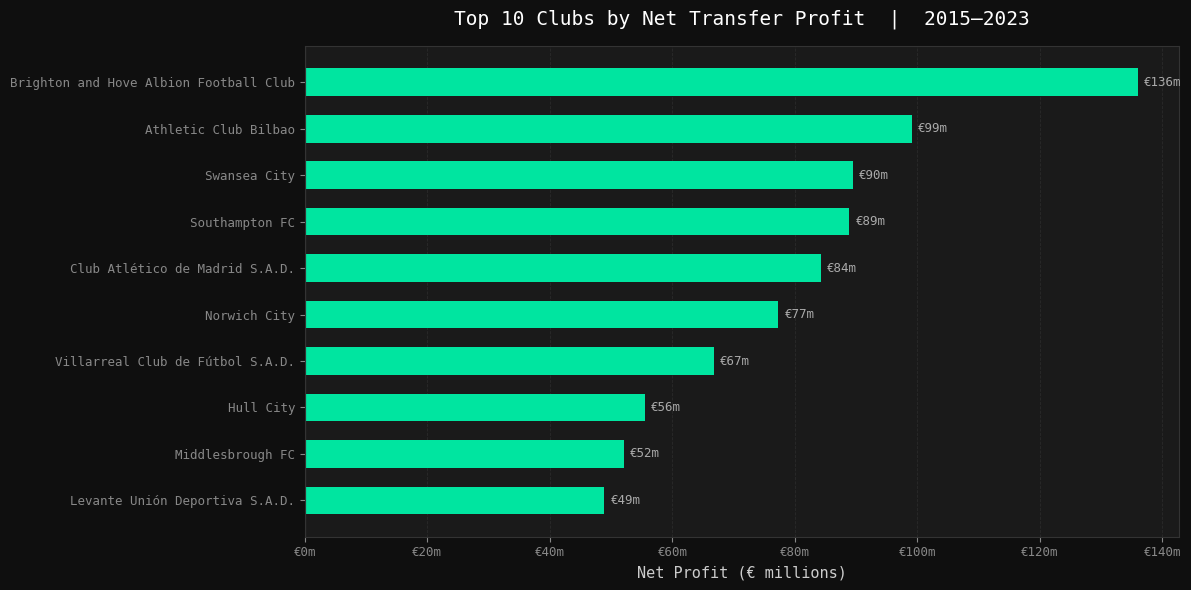

                                  club         league  income_millions  spend_millions  net_profit_millions
Brighton and Hove Albion Football Club premier-league            388.2           252.2                136.0
                  Athletic Club Bilbao         laliga            145.0            45.9                 99.1
                          Swansea City premier-league            102.2            12.7                 89.5
                        Southampton FC premier-league            319.9           231.0                 88.9
        Club Atlético de Madrid S.A.D.         laliga            379.3           295.1                 84.2
                          Norwich City premier-league             91.1            13.8                 77.3
      Villarreal Club de Fútbol S.A.D.         laliga            203.2           136.4                 66.8
                             Hull City premier-league             63.0             7.5                 55.5
                      Middle

In [5]:
df3 = query("""
    WITH club_sales AS (
        SELECT from_club_id AS club_id, SUM(fee_euros) AS total_income
        FROM   transfers
        WHERE  fee_euros IS NOT NULL AND from_club_id IS NOT NULL
        GROUP  BY from_club_id
    ),
    club_spend AS (
        SELECT to_club_id AS club_id, SUM(fee_euros) AS total_spend
        FROM   transfers
        WHERE  fee_euros IS NOT NULL AND to_club_id IS NOT NULL
        GROUP  BY to_club_id
    )
    SELECT
        c.name                                              AS club,
        comp.name                                           AS league,
        ROUND(COALESCE(cs.total_income, 0) / 1e6, 1)       AS income_millions,
        ROUND(COALESCE(sp.total_spend,  0) / 1e6, 1)       AS spend_millions,
        ROUND((COALESCE(cs.total_income, 0)
             - COALESCE(sp.total_spend, 0)) / 1e6, 1)      AS net_profit_millions
    FROM   clubs        c
    JOIN   competitions comp ON comp.competition_id = c.competition_id
    LEFT   JOIN club_sales cs ON cs.club_id = c.club_id
    LEFT   JOIN club_spend sp ON sp.club_id = c.club_id
    ORDER  BY net_profit_millions DESC
    LIMIT  10
""")

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#0f0f0f')

colors = [ACCENT if v >= 0 else ACCENT2 for v in df3['net_profit_millions']]
bars = ax.barh(df3['club'], df3['net_profit_millions'], color=colors, height=0.6)

for bar, val in zip(bars, df3['net_profit_millions']):
    xpos = bar.get_width() + 1 if val >= 0 else bar.get_width() - 1
    align = 'left' if val >= 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f'€{val:.0f}m', va='center', ha=align, fontsize=9, color='#aaaaaa')

ax.invert_yaxis()
ax.axvline(0, color='#555555', linewidth=0.8)
ax.set_xlabel('Net Profit (€ millions)')
ax.set_title('Top 10 Clubs by Net Transfer Profit  |  2015–2023', pad=15)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:.0f}m'))
ax.grid(axis='x', linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart3_net_profit.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f0f')
plt.show()
print(df3.to_string(index=False))

---
## Chart 4 — Season-by-Season Transfer Spend per League
How has spending evolved across seasons in the Premier League vs La Liga?

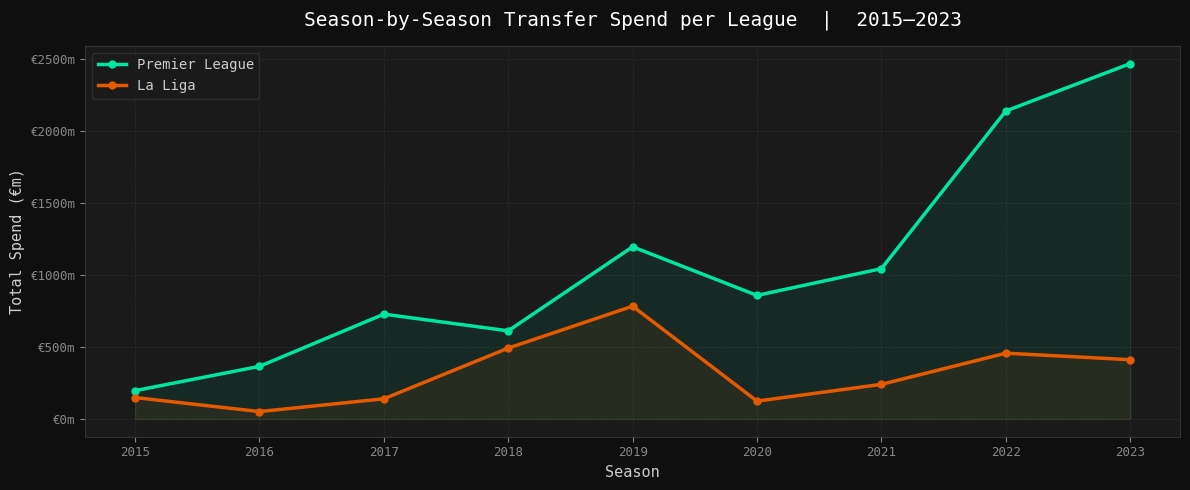

        league  season  total_spent_millions
        laliga    2015                 148.6
        laliga    2016                  51.4
        laliga    2017                 139.9
        laliga    2018                 492.2
        laliga    2019                 783.2
        laliga    2020                 123.9
        laliga    2021                 240.4
        laliga    2022                 456.8
        laliga    2023                 411.5
premier-league    2015                 196.5
premier-league    2016                 365.2
premier-league    2017                 727.9
premier-league    2018                 612.0
premier-league    2019                1195.7
premier-league    2020                 858.1
premier-league    2021                1044.0
premier-league    2022                2139.0
premier-league    2023                2468.0


In [9]:
df4 = query("""
    WITH seasonal_spend AS (
        SELECT
            comp.name                           AS league,
            t.season,
            ROUND(SUM(t.fee_euros) / 1e6, 1)   AS total_spent_millions
        FROM   transfers    t
        JOIN   clubs        c    ON c.club_id          = t.to_club_id
        JOIN   competitions comp ON comp.competition_id = c.competition_id
        WHERE  t.fee_euros IS NOT NULL
        GROUP  BY comp.name, t.season
    )
    SELECT * FROM seasonal_spend
    ORDER  BY league, season
""")

pl = df4[df4['league'] == 'premier-league']
ll = df4[df4['league'] == 'laliga']

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#0f0f0f')

ax.plot(pl['season'], pl['total_spent_millions'],
        color=ACCENT,  linewidth=2.5, marker='o', markersize=5, label='Premier League')
ax.plot(ll['season'], ll['total_spent_millions'],
        color=ACCENT2, linewidth=2.5, marker='o', markersize=5, label='La Liga')

ax.fill_between(pl['season'], pl['total_spent_millions'], alpha=0.08, color=ACCENT)
ax.fill_between(ll['season'], ll['total_spent_millions'], alpha=0.08, color=ACCENT2)

ax.set_xlabel('Season')
ax.set_ylabel('Total Spend (€m)')
ax.set_title('Season-by-Season Transfer Spend per League  |  2015–2023', pad=15)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:.0f}m'))
ax.set_xticks(df4['season'].unique())
ax.grid(linestyle='--')
ax.set_axisbelow(True)
ax.legend(facecolor='#1a1a1a', edgecolor='#333333', labelcolor='#cccccc')

plt.tight_layout()
plt.savefig('chart4_seasonal_spend.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f0f')
plt.show()
print(df4.to_string(index=False))

---
## Chart 5 — Attacking Contributions per 90 Minutes by Position
Which positions contribute most in terms of goals and assists per 90 minutes played?

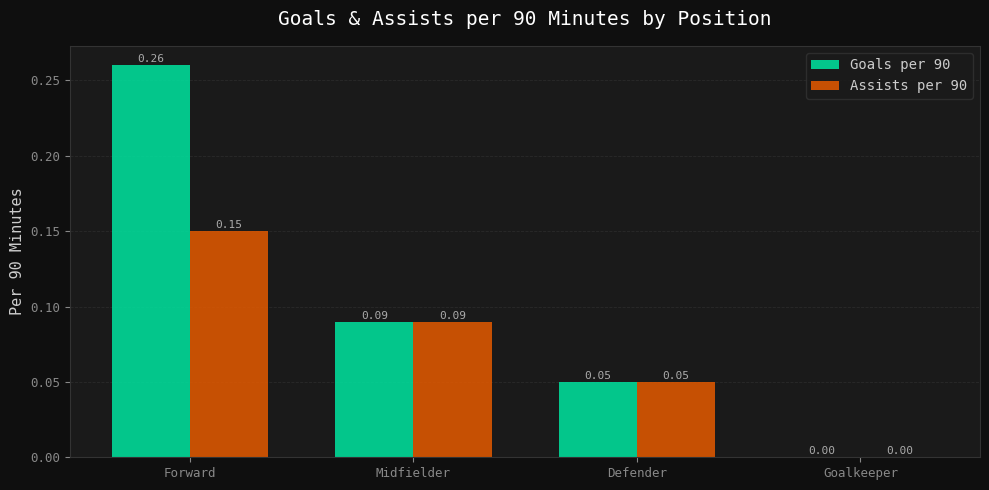

  position  goals_per_90  assists_per_90
   Forward          0.26            0.15
Midfielder          0.09            0.09
  Defender          0.05            0.05
Goalkeeper          0.00            0.00


In [7]:
df5 = query("""
    SELECT
        p.position,
        ROUND(SUM(a.goals)::numeric
              / NULLIF(SUM(a.minutes_played), 0) * 90, 2)   AS goals_per_90,
        ROUND(SUM(a.assists)::numeric
              / NULLIF(SUM(a.minutes_played), 0) * 90, 2)   AS assists_per_90
    FROM   appearances a
    JOIN   players     p ON p.player_id = a.player_id
    WHERE  a.minutes_played >= 90
    AND    p.position NOT IN ('Unknown')
    GROUP  BY p.position
    ORDER  BY goals_per_90 DESC
""")

x      = range(len(df5))
width  = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0f0f0f')

bars1 = ax.bar([i - width/2 for i in x], df5['goals_per_90'],
               width, label='Goals per 90', color=ACCENT,  alpha=0.85)
bars2 = ax.bar([i + width/2 for i in x], df5['assists_per_90'],
               width, label='Assists per 90', color=ACCENT2, alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.2f}', ha='center', fontsize=8, color='#aaaaaa')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.2f}', ha='center', fontsize=8, color='#aaaaaa')

ax.set_xticks(list(x))
ax.set_xticklabels(df5['position'])
ax.set_ylabel('Per 90 Minutes')
ax.set_title('Goals & Assists per 90 Minutes by Position', pad=15)
ax.grid(axis='y', linestyle='--')
ax.set_axisbelow(True)
ax.legend(facecolor='#1a1a1a', edgecolor='#333333', labelcolor='#cccccc')

plt.tight_layout()
plt.savefig('chart5_contributions_per90.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f0f')
plt.show()
print(df5.to_string(index=False))

---
## Summary

This dashboard presents five key analyses of the European football transfer market using real Transfermarkt data for the Premier League and La Liga between 2015 and 2023:

1. **Transfer Spend** — identifies which clubs invested most heavily in permanent transfers
2. **Value by Age** — reveals the age curve of player market value and when players peak
3. **Net Profit** — shows which clubs consistently sold players for more than they paid
4. **Seasonal Trends** — tracks how league-wide spending evolved season by season
5. **Performance Ratios** — compares attacking output per 90 minutes across positions

All charts are generated directly from live PostgreSQL queries against the normalised database.

In [4]:
# Close the database connection
conn.close()
print('Connection closed.')

Connection closed.
